# Lab 1. Introduction to imagery / image processing / computer vision

The goal here is to learn basics of digital image processing : read and write, histogram manipulations, geometric transformations, etc

In [1]:
import numpy as np
import imageio
import matplotlib.pyplot as plt

## 1. Importance of image dynamic when reading, writing and displaying an image

Execute the following cell and explain what happens (read the doc of function plt.imshow)

/var/folders/gd/kf1g0d9s227gqylz3d572v2m0000gn/T/ipykernel_32969/1710015794.py:1: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread( 'tulip.ppm' )
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


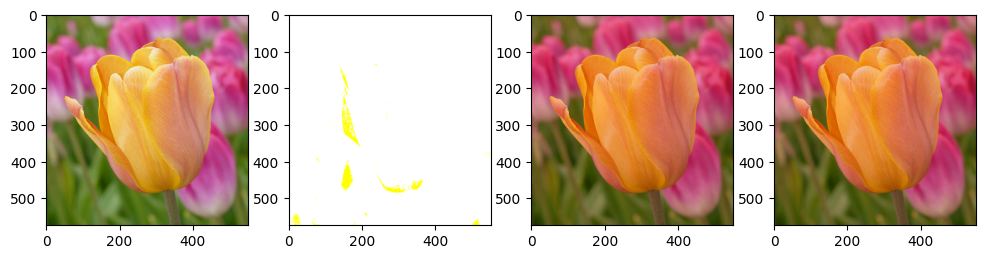

In [2]:
img = imageio.imread( 'tulip.ppm' )
img_tinted = img * [1., 0.8, 0.75]

# Show the original image. Note that img has type uint8. In this case, imshow
# expects black to be [0, 0, 0] and white to be [255, 255, 255].
fig, axes = plt.subplots(ncols=4, figsize=(12,4))
axes[0].imshow(img)

# Show the tinted image. Note that img_tinted has type float64. Now imshow
# expects black to be [0, 0, 0] and white to be [1, 1, 1]. Compare and
# interpret the three following solutions
axes[1].imshow(img_tinted)
axes[2].imshow(np.uint8(img_tinted))
axes[3].imshow(img_tinted / 255)

/var/folders/gd/kf1g0d9s227gqylz3d572v2m0000gn/T/ipykernel_32969/3536766253.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread( 'barbara.pgm' )


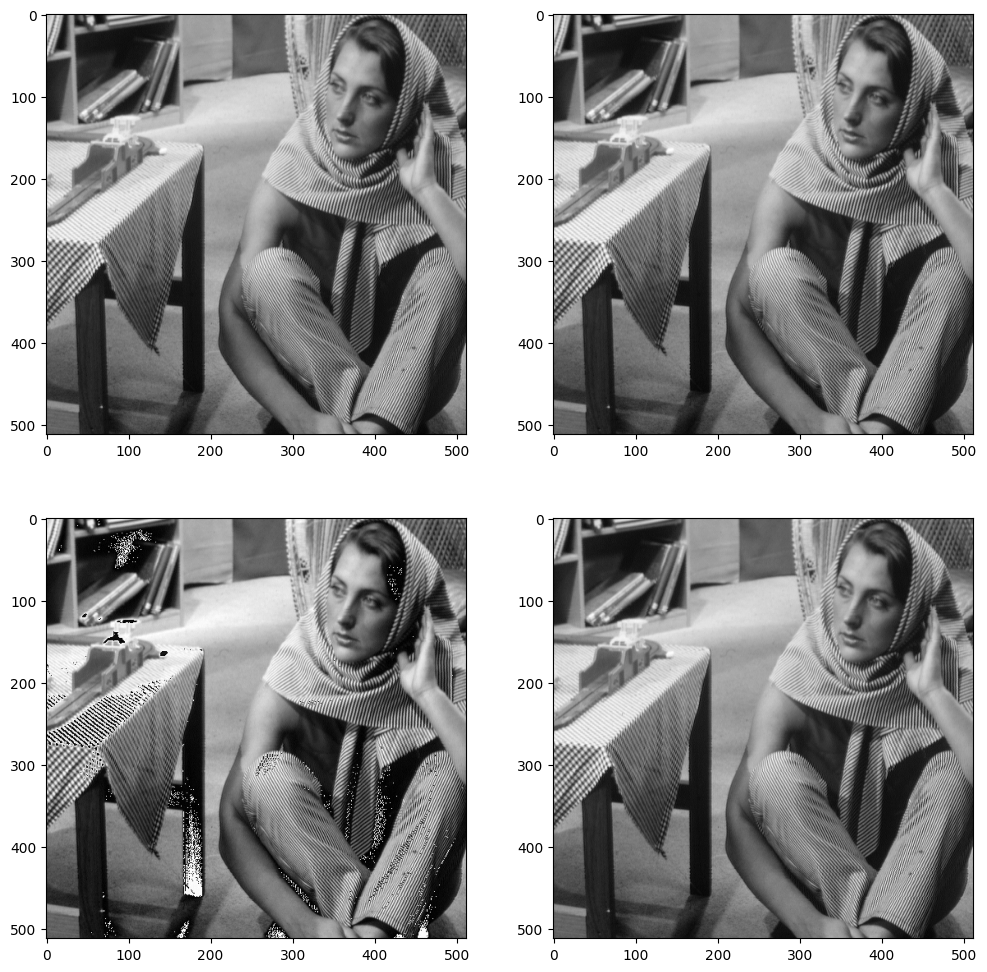

In [3]:
# Another example with a grayscale image, you will see that the behavior of plt.imshow is different
img = imageio.imread( 'barbara.pgm' )
mu = np.mean(img)
img2 = mu + 1.3*(img-mu)

# Show the original image
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,12))
axes[0,0].imshow(img, cmap=plt.get_cmap('gray'))

# Show the enhanced image
axes[0,1].imshow(img2, cmap=plt.get_cmap('gray'))
axes[1,0].imshow(np.uint8(img2), cmap=plt.get_cmap('gray'))
axes[1,1].imshow(img2 / 255, cmap=plt.get_cmap('gray'))

## 2. Histogram transformation

We will see here how to do simple but effective histogram manipulations, from scratch

/var/folders/gd/kf1g0d9s227gqylz3d572v2m0000gn/T/ipykernel_32969/4204851315.py:2: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread( 'unequalized.jpg' )


(array([0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.00

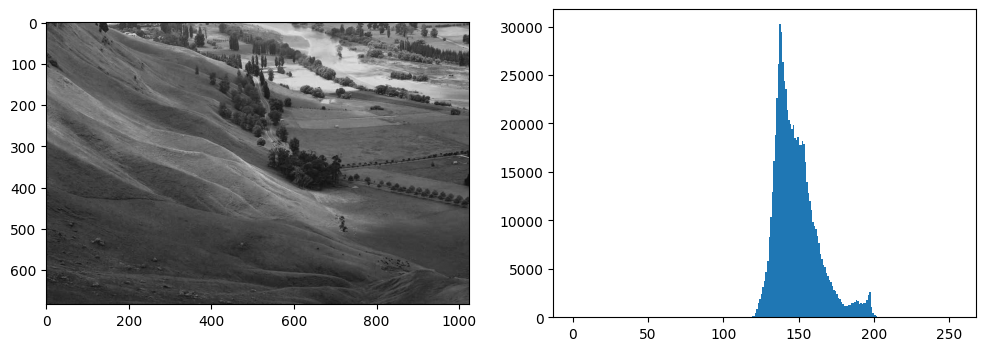

In [4]:
# Another example with a grayscale image, you will see that the behavior of plt.imshow is different
img = imageio.imread( 'unequalized.jpg' )

# Get histogram
h, _ = np.histogram(img.flatten(), bins=range(257))

# Display image and histogram
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
axes[0].imshow(img, cmap=plt.get_cmap('gray'))
axes[1].hist(img.flatten(), range(256))

<span style="color:blue">**Exercise**</span>: 
- Implement histogram equalization for a grayscale image
- Extend this to a RGB image

(array([ 1621.,  3417.,  2422.,  3100.,     0.,  3758.,  4656.,     0.,
            0.,  5832.,     0.,     0.,  8332.,     0.,     0., 10344.,
            0.,     0.,     0.,     0., 12944.,     0.,     0.,     0.,
            0.,     0., 16161.,     0.,     0.,     0.,     0.,     0.,
            0., 18849.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 22631.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0., 26106.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0.,     0.,     0., 30266.,     0.,
            0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 29395.,     0.,     0.,     0.,     0.,     0.,     0.,
            0.,     0., 26391.,     0.,     0.,     0.,     0.,     0.,
            0.,     0.,     0., 24413.,     0.,     0.,     0.,     0.,
            0.,     0.,     0.,     0., 23512.,     0.,     0.,     0.,
            0.,     0.,     0.,     0., 21411.,     0.,     0., 

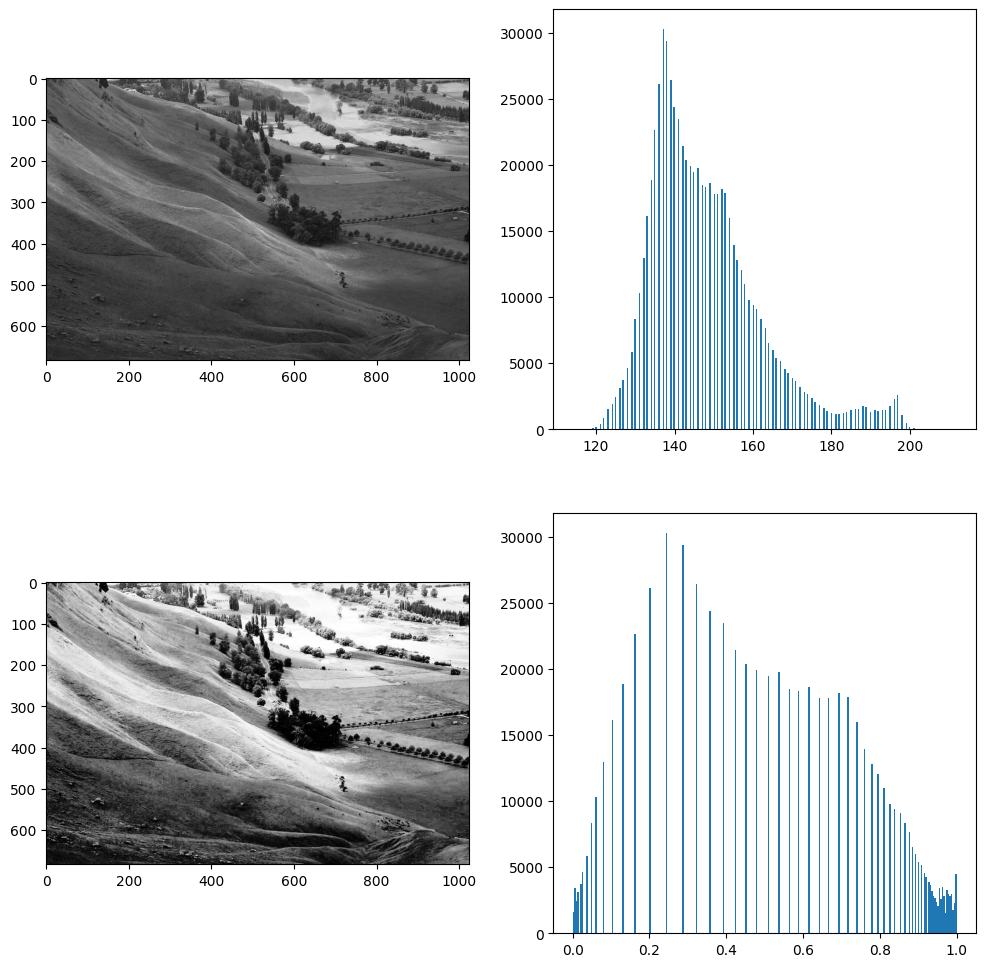

In [10]:
# Your turn
hs = np.cumsum(h)/img.size
img_eq = hs[img]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,12))
axes[0,0].imshow(img, cmap=plt.get_cmap('gray'))
axes[0,1].hist(img.flatten(), bins=256)
axes[1,0].imshow(img_eq, cmap=plt.get_cmap('gray'))
axes[1,1].hist(img_eq.flatten(), bins=256)


## 3. Some geometric transformations

Will see here some simple geometric transformations applied to a color image. Do not forget that, most of the time, there is an interpolation step to sample the transformed image on the pixel grid!

From now, we will use the module scikit-image (skimage), which is a reference module for manipulating images.

[[  0.96592583  -0.25881905  60.        ]
 [  0.25881905   0.96592583 -20.        ]
 [  0.           0.           1.        ]]


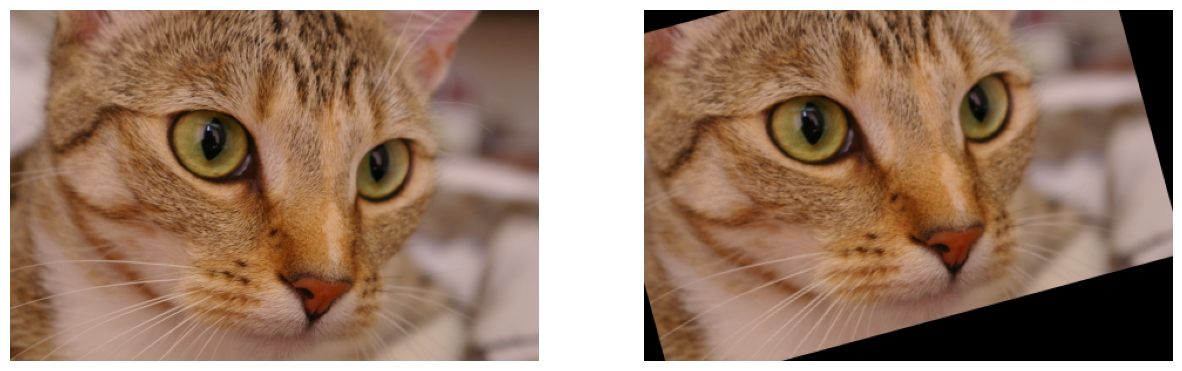

In [11]:
from skimage import transform, data

# Define an affine transformation
tform = transform.EuclideanTransform(
    rotation=np.pi / 12.,
    translation = (60, -20)
    )
print(tform.params)

# Now let’s apply this transformation to an image
img = data.chelsea() / 255.
tf_img = transform.warp(img, tform)

# Show the enhanced image
fig, axes = plt.subplots(ncols=2, figsize=(15,10))
axes[0].imshow(img)
axes[1].imshow(tf_img)
p = [axi.set_axis_off() for axi in axes.ravel()]

<span style="color:blue">**Exercise**</span>: 
- try other geometric transformations such as scaling, projection, etc
- Try a naive subsampling on image Barbara, see the aliasing effect
- Do a proper subsampling with opencv

/var/folders/gd/kf1g0d9s227gqylz3d572v2m0000gn/T/ipykernel_32969/2802846189.py:3: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread( 'barbara.pgm' )


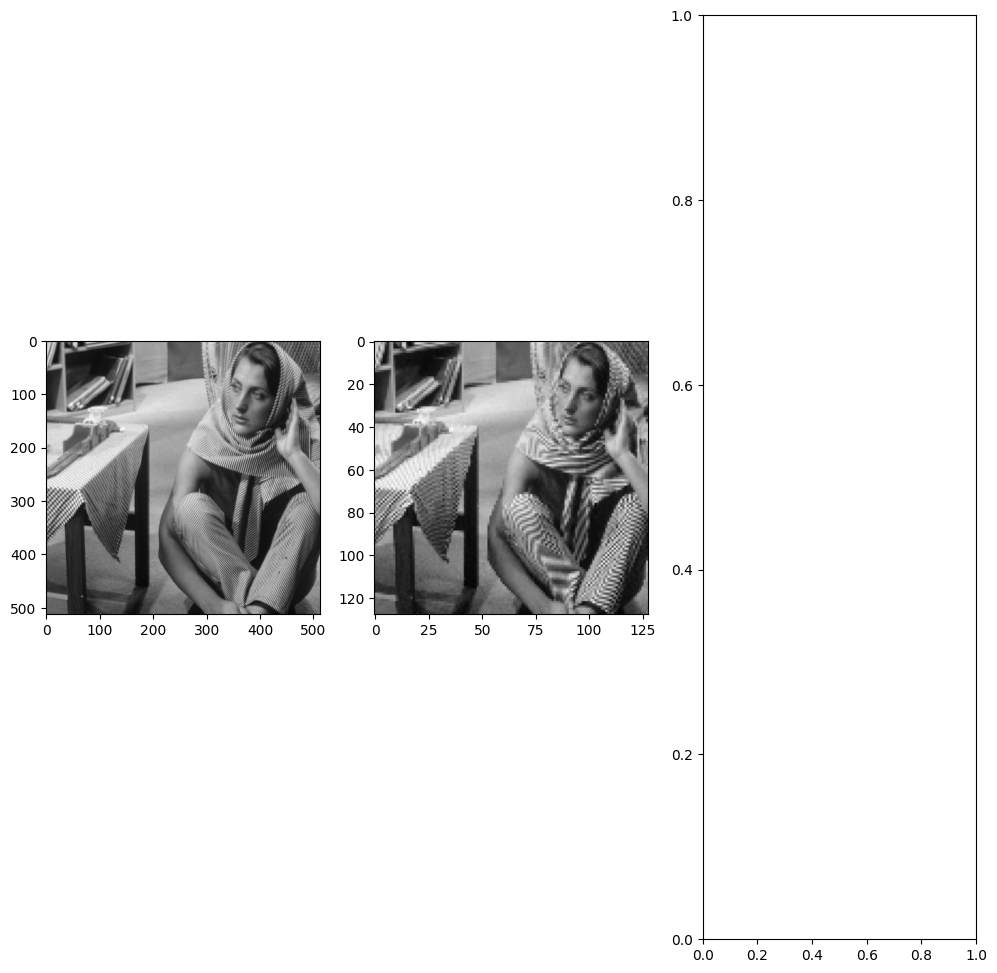

In [16]:
# Your turn

img = imageio.imread( 'barbara.pgm' )

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12,12))
axes[0].imshow(img, cmap=plt.get_cmap('gray'))

axes[1].imshow(img[::4,::4], cmap=plt.get_cmap('gray'))
#axes[2].imshow(transform.resize(img(256,256)), cmap=plt.get_cmap('gray'))